# Exploratory Data Analysis

## Imports

In [1]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import defaultdict

In [2]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
LABEL_COLORS = {
    "PERSON":     "#4A90D9",
    "ITEM":       "#5CB85C",
    "PRICE":      "#F0A500",
    "MULTIPLIER": "#D9534F",
    "O":          "#AAAAAA",
}

## Loading Data

In [67]:
with open('../data/training_data.json', 'r', encoding="utf-8") as f:
    raw = json.load(f)

In [ ]:
# normalize, accept either a top-level list or {"data": [...]}
if isinstance(raw, list):
    samples = raw
elif isinstance(raw, dict) and "data" in raw:
    samples = raw["data"]
else:
    raise ValueError("Unexpected JSON structure")

In [69]:
print(f'total samples: {len(samples)}')
print("\nFirst sample:")
print(json.dumps(samples[0], indent=2, ensure_ascii=False))

total samples: 13226

First sample:
{
  "text": "Mohon kesediaannya untuk melunasi tagihan kopi kemarin. Saya lampirkan rinciannya, termasuk biaya surge karena hujan yang cukup mengagetkan.\n- Rensy: kripik cireng toples (49 K)\n- Lainnya: carbonara truffle (148 K)\nSilakan ditransfer, x9.",
  "entities": [
    {
      "start": 143,
      "end": 148,
      "label": "PERSON",
      "text": "Rensy"
    },
    {
      "start": 150,
      "end": 170,
      "label": "ITEM",
      "text": "kripik cireng toples"
    },
    {
      "start": 172,
      "end": 176,
      "label": "PRICE",
      "text": "49 K"
    },
    {
      "start": 189,
      "end": 206,
      "label": "ITEM",
      "text": "carbonara truffle"
    },
    {
      "start": 208,
      "end": 213,
      "label": "PRICE",
      "text": "148 K"
    },
    {
      "start": 235,
      "end": 237,
      "label": "MULTIPLIER",
      "text": "x9"
    }
  ]
}


### Flatten into two DataFrames

In [86]:
# sample df
# describe how long the text is, how many entities it contains.
# use this to understand the shape of the corpus
df_samples = pd.DataFrame([{
    "id":           i,
    "text":         s["text"],
    "text_len":     len(s["text"]),
    "n_entities":   len(s.get("entities", [])),
    "n_chars":      len(s["text"]),
    "n_lines":      s["text"].count("\n") + 1,
} for i, s in enumerate(samples)])

# entity df
# used to store the entities of a text
# describes every labeled span across all messages
rows = []
for i, s in enumerate(samples):
    for ent in s.get("entities", []):
        span_text = s["text"][ent["start"]:ent["end"]]
        rows.append({
            "sample_id":    i,
            "label":        ent["label"],
            "start":        ent["start"],
            "end":          ent["end"],
            "span_len_chr": ent["end"] - ent["start"],
            "entity_text":  ent.get("text", span_text),
            "raw_span":     span_text,
            "match":        ent.get("text", span_text) == span_text,
        })

df_ents = pd.DataFrame(rows)

print(df_samples.describe())
print(f"\ntotal entities: {len(df_ents)}")
print(df_ents["label"].value_counts())

                 id      text_len    n_entities       n_chars       n_lines
count  13226.000000  13226.000000  13226.000000  13226.000000  13226.000000
mean    6612.500000    224.491381      7.888477    224.491381      3.201421
std     3818.161665    138.821253      4.083593    138.821253      2.860849
min        0.000000     13.000000      1.000000     13.000000      1.000000
25%     3306.250000    123.000000      5.000000    123.000000      1.000000
50%     6612.500000    197.000000      7.000000    197.000000      1.000000
75%     9918.750000    288.000000     10.000000    288.000000      5.000000
max    13225.000000    855.000000     36.000000    855.000000     18.000000

total entities: 104333
label
PRICE         36155
PERSON        35584
ITEM          21728
MULTIPLIER    10866
Name: count, dtype: int64


In [71]:
df_samples.head()

,id,text,text_len,n_entities,n_chars,n_lines
0,0,Mohon kesediaannya untuk melunasi tagihan kopi...,238,6,238,4
1,1,Terlampir rincian pemesanan cafe kemarin. Saya...,244,6,244,4
2,2,"Demi efisiensi waktu, saya sudah buatkan list ...",235,6,235,4
3,3,Rekap beef ribs lollipop\nTotal: 97k\nSplit: 2...,72,5,72,5
4,4,Billing ikan tahuman\nAmount: seceng\n5 porsi\...,82,5,82,5


In [72]:
df_ents.head(10)

,sample_id,label,start,end,span_len_chr,entity_text,raw_span,match
0,0,PERSON,143,148,5,Rensy,Rensy,True
1,0,ITEM,150,170,20,kripik cireng toples,kripik cireng toples,True
2,0,PRICE,172,176,4,49 K,49 K,True
3,0,ITEM,189,206,17,carbonara truffle,carbonara truffle,True
4,0,PRICE,208,213,5,148 K,148 K,True
5,0,MULTIPLIER,235,237,2,x9,x9,True
6,1,PERSON,136,142,6,Wagino,Wagino,True
7,1,ITEM,144,163,19,aburi tamago mentai,aburi tamago mentai,True
8,1,PRICE,166,172,6,Rp133k,Rp133k,True
9,1,ITEM,184,200,16,es jasjus mangga,es jasjus mangga,True


## EDA

### Entity Label Distribution

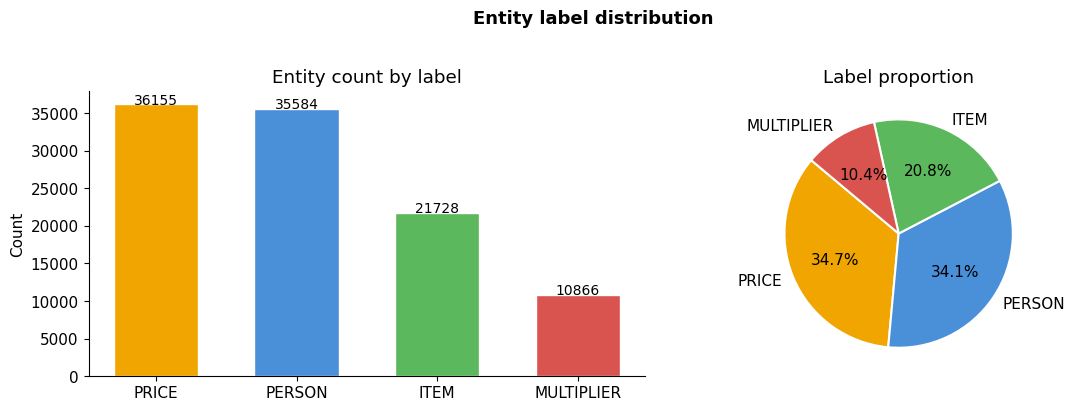

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df_ents["label"].value_counts()
colors = [LABEL_COLORS.get(l, "#888") for l in label_counts.index]

# plot raw label counts per entity
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="white", width=0.6)
axes[0].set_title("Entity count by label")
axes[0].set_ylabel("Count")
for i, (label, val) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, val + 0.3, str(val), ha="center", fontsize=10)

# plot the proportion of labels
axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Label proportion")

plt.suptitle("Entity label distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Entities Per Label Distribution

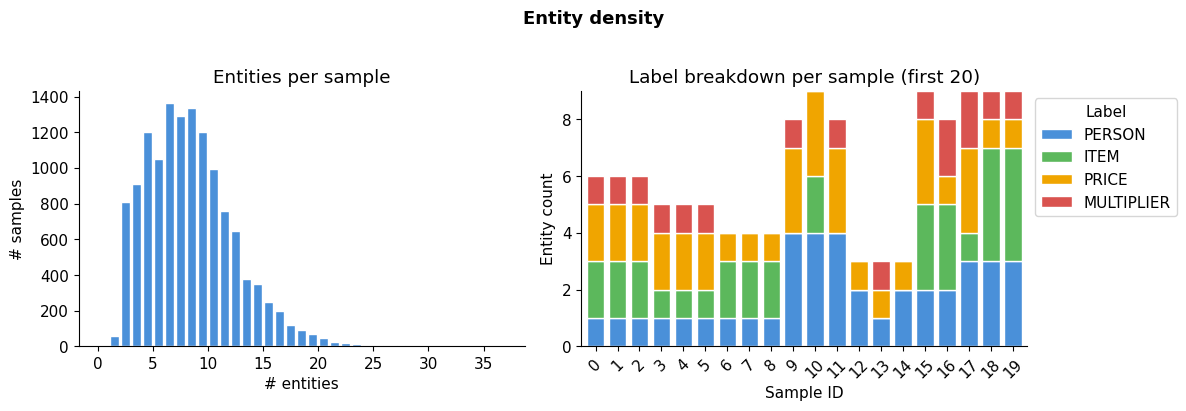

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram of entities per sample
axes[0].hist(df_samples["n_entities"], bins=range(0, df_samples["n_entities"].max() + 2),
             color="#4A90D9", edgecolor="white", rwidth=0.8)
axes[0].set_title("Entities per sample")
axes[0].set_xlabel("# entities")
axes[0].set_ylabel("# samples")
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# stacked bar showing label breakdown per sample (top 20 samples)
pivot = df_ents.groupby(["sample_id", "label"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=["PERSON", "ITEM", "PRICE", "MULTIPLIER"], fill_value=0)
pivot.head(20).plot(
    kind="bar", stacked=True, ax=axes[1],
    color=[LABEL_COLORS[c] for c in pivot.columns],
    edgecolor="white", width=0.8
)
axes[1].set_title("Label breakdown per sample (first 20)")
axes[1].set_xlabel("Sample ID")
axes[1].set_ylabel("Entity count")
axes[1].legend(title="Label", bbox_to_anchor=(1, 1))
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Entity density", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Span Character Length By Label

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4720\1504950194.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_label, labels=order, patch_artist=True, widths=0.5,


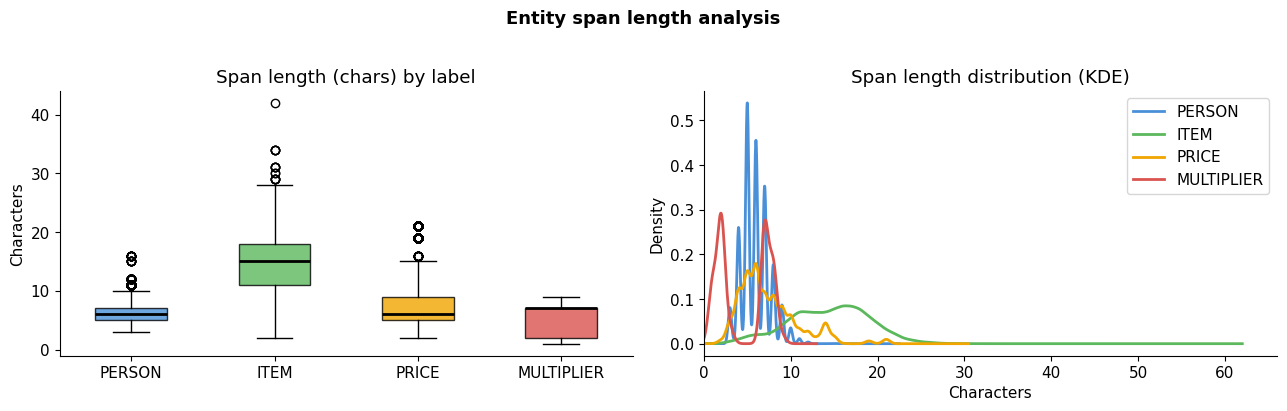

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# box plot
order = ["PERSON", "ITEM", "PRICE", "MULTIPLIER"]
data_by_label = [df_ents[df_ents["label"] == l]["span_len_chr"].values for l in order]

bp = axes[0].boxplot(data_by_label, labels=order, patch_artist=True, widths=0.5,
                     medianprops={"color": "black", "linewidth": 2})
for patch, label in zip(bp["boxes"], order):
    patch.set_facecolor(LABEL_COLORS[label])
    patch.set_alpha(0.8)
axes[0].set_title("Span length (chars) by label")
axes[0].set_ylabel("Characters")

# KDE per label
for label in order:
    vals = df_ents[df_ents["label"] == label]["span_len_chr"]
    if len(vals) > 1:
        vals.plot.kde(ax=axes[1], label=label, color=LABEL_COLORS[label], linewidth=2)
axes[1].set_title("Span length distribution (KDE)")
axes[1].set_xlabel("Characters")
axes[1].legend()
axes[1].set_xlim(left=0)

plt.suptitle("Entity span length analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Text (sample) length distribution

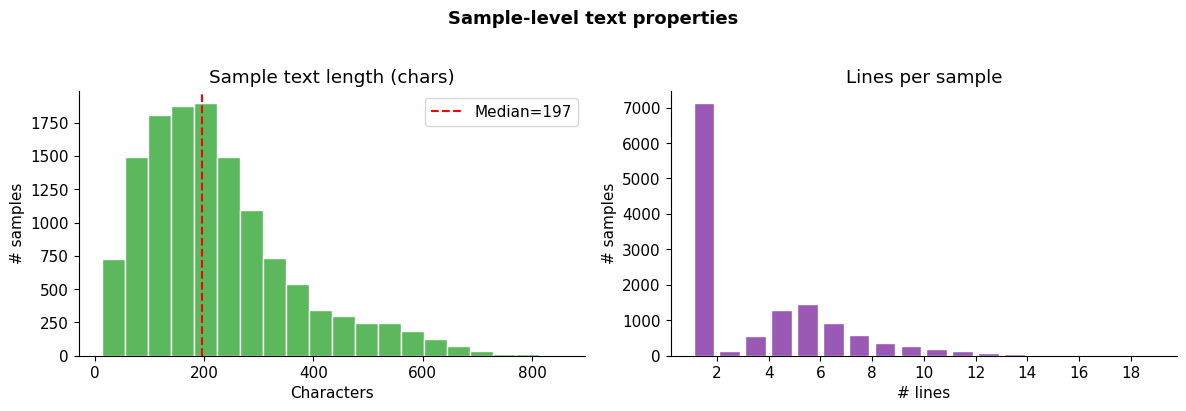

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# plot sample text length (chars)
axes[0].hist(df_samples["text_len"], bins=20, color="#5CB85C", edgecolor="white")
axes[0].set_title("Sample text length (chars)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("# samples")
axes[0].axvline(df_samples["text_len"].median(), color="red", linestyle="--", label=f'Median={df_samples["text_len"].median():.0f}')
axes[0].legend()

# lines per sample
axes[1].hist(df_samples["n_lines"], bins=range(1, df_samples["n_lines"].max() + 2),
             color="#9B59B6", edgecolor="white", rwidth=0.8)
axes[1].set_title("Lines per sample")
axes[1].set_xlabel("# lines")
axes[1].set_ylabel("# samples")
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.suptitle("Sample-level text properties", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Top Entity Surface Forms Per Label

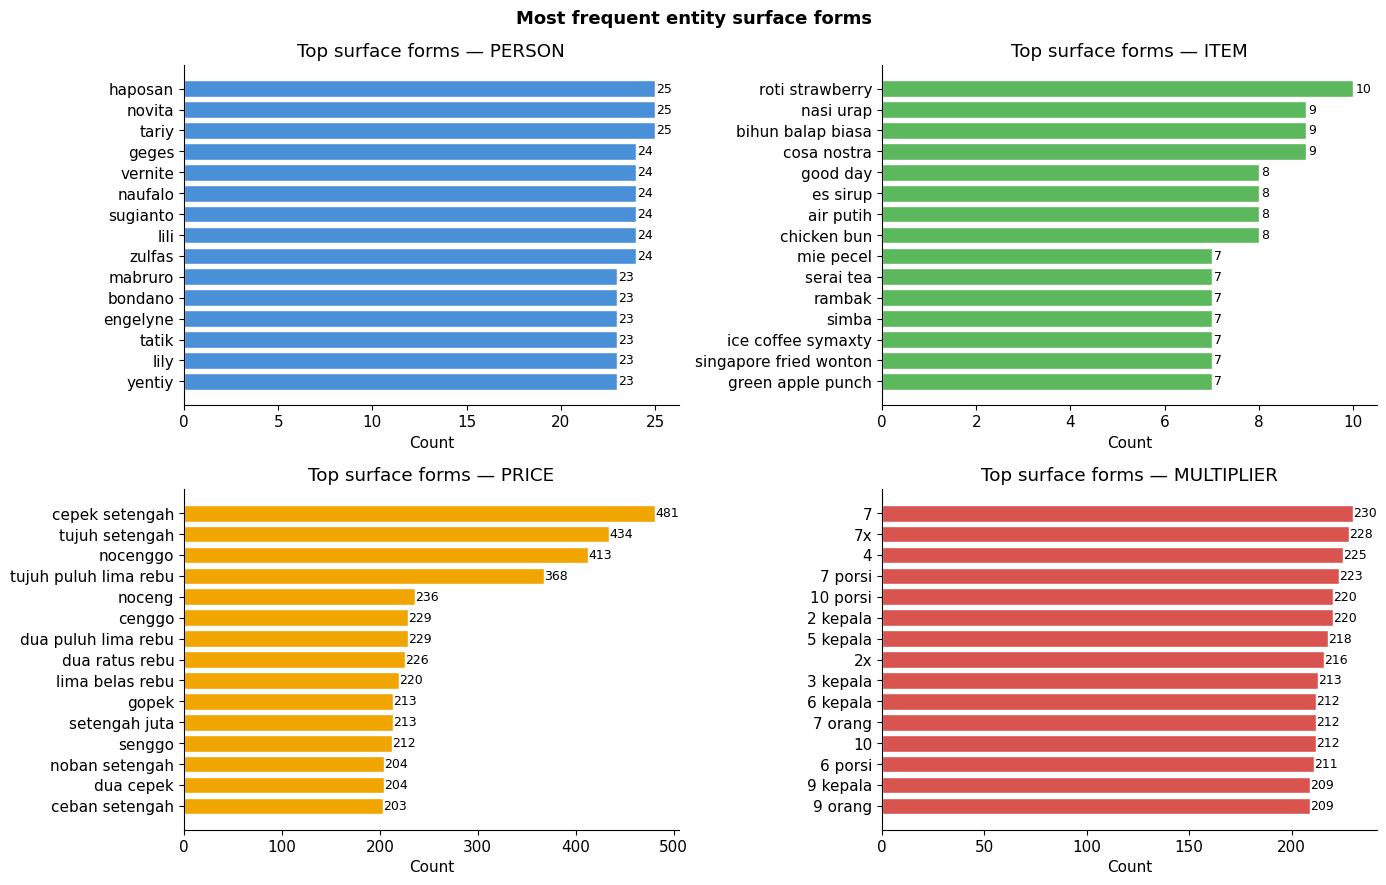

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, label in zip(axes, ["PERSON", "ITEM", "PRICE", "MULTIPLIER"]):
    subset = df_ents[df_ents["label"] == label]["entity_text"].str.lower().str.strip()
    counts = subset.value_counts().head(15)
    ax.barh(counts.index[::-1], counts.values[::-1],
            color=LABEL_COLORS[label], edgecolor="white")
    ax.set_title(f"Top surface forms — {label}")
    ax.set_xlabel("Count")
    for i, (val, name) in enumerate(zip(counts.values[::-1], counts.index[::-1])):
        ax.text(val + 0.05, i, str(val), va="center", fontsize=9)

plt.suptitle("Most frequent entity surface forms", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### PRICE Noise Pattern Taxonomy

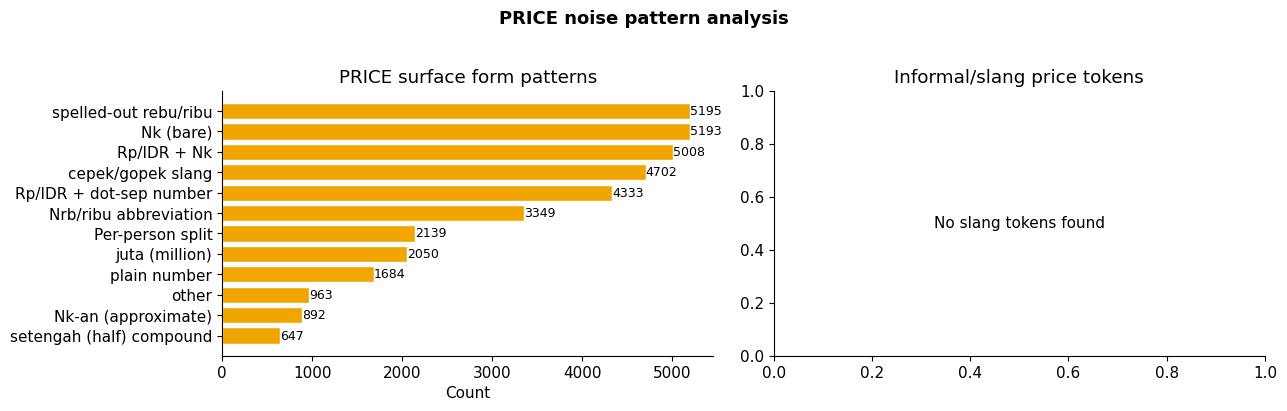


All PRICE patterns with examples:
  Nk (bare)                      → ['49 K', '148 K', '73K', '97k', '±10k']
  Nk-an (approximate)            → ['12k-an', '15k-an', '335k-an', '16k-an', '92k-an']
  Nrb/ribu abbreviation          → ['72rb', '332rebu', '32rebu', '65rb', '342RB']
  Per-person split               → ['Rp35k/orang', '30k per orang', '20k/orang', '35rb/orang', '35k perorang']
  Rp/IDR + Nk                    → ['Rp133k', 'RP14k', 'Rp 17k', 'rp 87k', 'Rp14k']
  Rp/IDR + dot-sep number        → ['rp67.000', 'Rp 40.000,-', 'IDR 254.000', 'IDR 33.000', 'Rp36.000']
  cepek/gopek slang              → ['cenggo', 'seceng', 'goceng', 'noban', 'seceban']
  juta (million)                 → ['Rp5jt', '2.8 juta', '5J', 'Rp 5 juta', '2.8J']
  other                          → ['47.000,-', '68.000,-', 'seribu', '36.000,-', '14.000,-']
  plain number                   → ['45.000', '26.000', '54.000', '318.000,00', '31.000,00']
  setengah (half) compound       → ['setengah juta', 'tujuh seten

In [ ]:
REBU_PATTERN = re.compile(r'(satu|dua|tiga|empat|lima|enam|tujuh|delapan|sembilan|'
                           r'sepuluh|sebelas|dua belas|lima belas|dua puluh[\w\s]*|'
                           r'tiga puluh[\w\s]*|[\w\s]+)\s+(rebu|ribu|rb|rbu)', re.I)
JUTA_PATTERN = re.compile(r'([\d.,]+\s*j(uta|t)?|setengah juta|\d+\.\d+\s*jt)', re.I)

def classify_price(text):
    t = text.strip().lower()
    
    CEPEK_WORDS = {"cepek", "gopek", "ceban", "noban", "senggo", "cenggo",
                   "nocenggo", "noceng", "limapek", "dua ceng", "seceng",
                   "seceban", "secepek", "goceng", "gocen", "gocap", "saceng"}

    if any(w in t for w in CEPEK_WORDS):           return "cepek/gopek slang"
    if "setengah" in t or "tengah" in t:           return "setengah (half) compound"
    if JUTA_PATTERN.search(t):                     return "juta (million)"
    if REBU_PATTERN.search(t):                     return "spelled-out rebu/ribu"
    
    # support for per-person splits (with or without Rp, with slash or "per")
    if re.search(r'(?:/|per\s*)(orang|kepala|org)', t): return "Per-person split"
    
    # allow optional approximate symbols at the start of formats
    if re.fullmatch(r'[~±]?\s*(rp|idr)\s*[\d.]+,?-?', t):  return "Rp/IDR + dot-sep number"
    if re.fullmatch(r'[~±]?\s*(rp|idr)\s*[\d]+\s*k', t):   return "Rp/IDR + Nk"
    if re.fullmatch(r'[~±]?\s*[\d.,]+\s*k-an', t):         return "Nk-an (approximate)"
    if re.fullmatch(r'[~±]?\s*[\d.,]+\s*k', t):            return "Nk (bare)"
    
    # catch rb, ribu, rebu, and the "an" suffix
    if re.fullmatch(r'[~±]?\s*[\d.,]+\s*(rb|ribu|rebu)(?:\s*an)?', t): return "Nrb/ribu abbreviation"
    if re.fullmatch(r'[~±]?\s*[\d.,]+(,00)?', t):          return "plain number"
    
    return "other"

prices = df_ents[df_ents["label"] == "PRICE"].copy()
prices["pattern"] = prices["entity_text"].apply(classify_price)

pattern_counts = prices["pattern"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(pattern_counts.index[::-1], pattern_counts.values[::-1],
             color="#F0A500", edgecolor="white")
axes[0].set_title("PRICE surface form patterns")
axes[0].set_xlabel("Count")
for i, val in enumerate(pattern_counts.values[::-1]):
    axes[0].text(val + 0.05, i, str(val), va="center", fontsize=9)

# Show all slang/informal prices explicitly
slang = prices[prices["pattern"] == "informal/slang"]["entity_text"].value_counts().head(20)

if not slang.empty:
    axes[1].barh(slang.index[::-1], slang.values[::-1], color="#D9534F", edgecolor="white")
    axes[1].set_title("Top 20 Informal/slang price tokens")
    axes[1].set_xlabel("Count")
else:
    axes[1].text(0.5, 0.5, "No slang tokens found", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Informal/slang price tokens")

plt.suptitle("PRICE noise pattern analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nAll PRICE patterns with examples:")
for pattern, group in prices.groupby("pattern"):
    examples = group["entity_text"].unique()[:5].tolist()
    print(f"  {pattern:30s} → {examples}")

### Special character inventory in entity spans

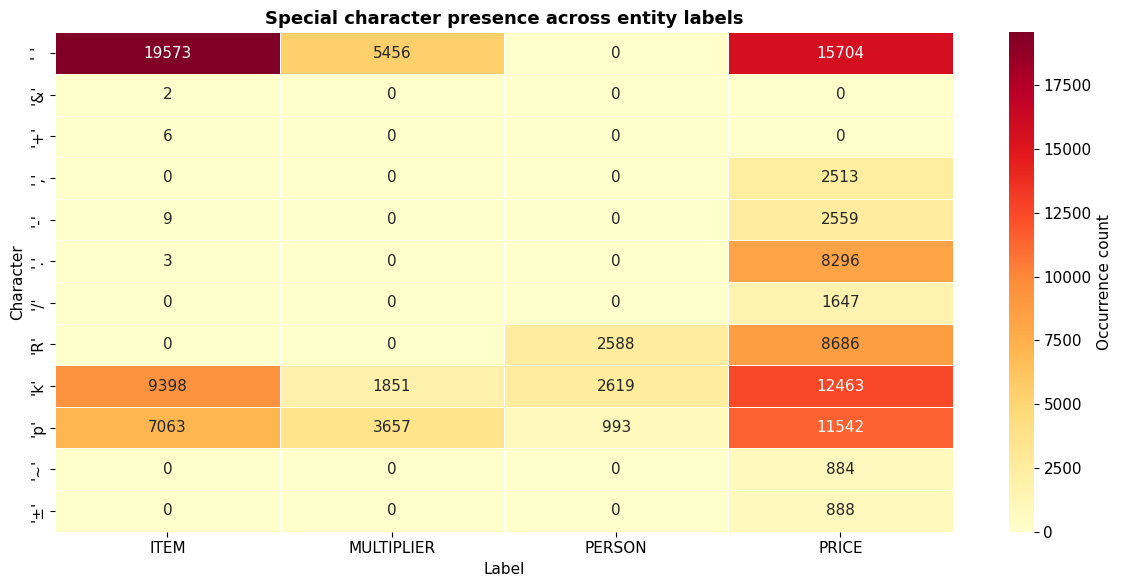

In [79]:
SPECIAL_CHARS = list("Rp.,k/-±~()[]_?")

char_label_counts = defaultdict(lambda: defaultdict(int))

for _, row in df_ents.iterrows():
    for ch in set(row["entity_text"]):
        if ch in SPECIAL_CHARS or not ch.isalnum():
            char_label_counts[ch][row["label"]] += 1

rows_ch = []
for ch, label_dict in char_label_counts.items():
    for label, count in label_dict.items():
        rows_ch.append({"char": repr(ch), "label": label, "count": count})

df_chars = pd.DataFrame(rows_ch)

if not df_chars.empty:
    pivot_ch = df_chars.pivot_table(index="char", columns="label", values="count", fill_value=0).astype(int)
    
    fig, ax = plt.subplots(figsize=(12, max(4, len(pivot_ch) * 0.5)))
    sns.heatmap(pivot_ch, annot=True, fmt="d", cmap="YlOrRd",
                linewidths=0.5, ax=ax, cbar_kws={"label": "Occurrence count"})
    ax.set_title("Special character presence across entity labels", fontsize=13, fontweight="bold")
    ax.set_xlabel("Label")
    ax.set_ylabel("Character")
    plt.tight_layout()
    plt.show()

### Span Offset Alignment Check

Total entities   : 104333
Offset mismatches: 123 (0.1%)

 sample_id  label         entity_text            raw_span
      3462  PRICE               220 k               rus b
      3462  PRICE            nocenggo            t parkir
      3462 PERSON             Mustika             ore gue
      3463  PRICE          412.000,00           er orang.
      3463  PRICE             265k-an              dua bu
      3464  PRICE dua puluh lima rebu  h lima rebu semua.
      3464  PRICE           Rp197.000           0 buat pl
      4134  PRICE             143ribu             ibu, te
      4134  PRICE               Rp1jt                erus
      4134  PRICE              13rebu              er ora
      4134 PERSON                 Dea                  se
      4134  PRICE      setengah cepek       cepek ya biar
      4135  PRICE       30k per orang       per orang, ya
      4135  PRICE                ~86k                 rus
      4135  PRICE               RP11k               angat
      4135 PERS

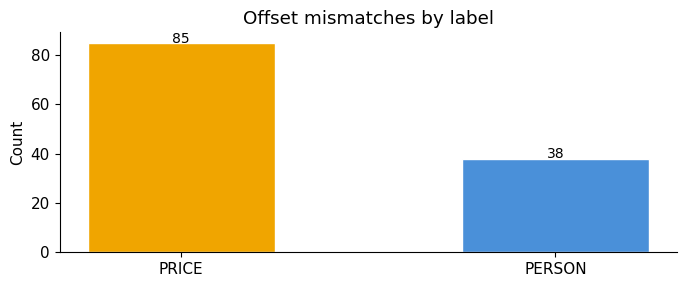

In [ ]:
# checks whether entity["text"] matches what's actually at [start:end] in the raw string.
# mismatches reveal bracket/suffix noise you need to handle before BIO conversion.
mismatches = df_ents[~df_ents["match"]].copy()
mismatches["raw_span"] = mismatches["raw_span"].str.strip()

print(f"Total entities   : {len(df_ents)}")
print(f"Offset mismatches: {len(mismatches)} ({100*len(mismatches)/len(df_ents):.1f}%)\n")

if not mismatches.empty:
    print(mismatches[["sample_id", "label", "entity_text", "raw_span"]].to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 3))
    mismatch_by_label = mismatches["label"].value_counts()
    ax.bar(mismatch_by_label.index, mismatch_by_label.values,
           color=[LABEL_COLORS.get(l, "#888") for l in mismatch_by_label.index],
           edgecolor="white", width=0.5)
    ax.set_title("Offset mismatches by label")
    ax.set_ylabel("Count")
    for i, val in enumerate(mismatch_by_label.values):
        ax.text(i, val + 0.1, str(val), ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("All spans align perfectly — no offset issues.")

#### Fix Offsets

In [ ]:
# helper function to find the correct character offset for a misaligned entity
# returns (new_start, new_end) if found, or None if unresolvable
def fix_offset(sample_text, entity):
    target = entity["text"]
    
    # search in a window around the originally annotated position
    search_start = max(0, entity["start"] - 30)
    search_end   = min(len(sample_text), entity["end"] + 30)
    window       = sample_text[search_start:search_end]
    
    idx = window.find(target)
    if idx != -1:
        new_start = search_start + idx
        new_end   = new_start + len(target)
        return new_start, new_end
    
    # try case-insensitive fallback
    idx = window.lower().find(target.lower())
    if idx != -1:
        new_start = search_start + idx
        new_end   = new_start + len(target)
        return new_start, new_end
    
    return None  # couldn't resolve

In [ ]:
fixed_samples  = []   # samples with corrections applied
unfixable      = []   # entities we couldn't resolve — need manual review

for i, sample in enumerate(samples):
    new_entities = []
    
    for ent in sample.get("entities", []):
        raw_span = sample["text"][ent["start"]:ent["end"]]
        
        # check if aligned
        if raw_span == ent.get("text", raw_span):
            new_entities.append(ent)
            continue
        
        # try fix
        result = fix_offset(sample["text"], ent)
        
        if result is not None:
            new_start, new_end = result
            fixed_ent = {
                **ent,
                "start": new_start,
                "end":   new_end,
            }
            new_entities.append(fixed_ent)
        else:
            unfixable.append({
                "sample_id":   i,
                "label":       ent["label"],
                "entity_text": ent.get("entity_text", ""),
                "bad_start":   ent["start"],
                "bad_end":     ent["end"],
                "raw_span":    raw_span,
            })
            # still keep the original so the sample isn't silenty dropped
            new_entities.append(ent)
    
    fixed_samples.append({**sample, "entities": new_entities})

print(f"Unfixable entities : {len(unfixable)}")
print(f"Samples processed  : {len(fixed_samples)}")

Unfixable entities : 0
Samples processed  : 13226


In [83]:
df_unfixable = pd.DataFrame(unfixable)

if not df_unfixable.empty:
    print("Unfixable breakdown by label:")
    print(df_unfixable["label"].value_counts())
    print()
    print(df_unfixable.to_string(index=False))
else:
    print("All mismatches resolved.")

All mismatches resolved.


In [84]:
output_path = "../data/dataset_fixed.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(fixed_samples, f, ensure_ascii=False, indent=2)

print(f"Saved cleaned dataset → {output_path}")

Saved cleaned dataset → ../data/dataset_fixed.json


### Summary stats table

In [85]:
summary = df_ents.groupby("label").agg(
    count=("entity_text", "count"),
    unique_forms=("entity_text", "nunique"),
    avg_span_len=("span_len_chr", "mean"),
    max_span_len=("span_len_chr", "max"),
    min_span_len=("span_len_chr", "min"),
).round(1)

summary["samples_with_label"] = df_ents.groupby("label")["sample_id"].nunique()
summary["avg_per_sample"] = (summary["count"] / len(df_samples)).round(2)

print(summary.to_string())

            count  unique_forms  avg_span_len  max_span_len  min_span_len  samples_with_label  avg_per_sample
label                                                                                                        
ITEM        21728         12858          14.4            42             2               10488            1.64
MULTIPLIER  10866            54           4.6             9             1                9046            0.82
PERSON      35584          3076           5.9            16             3               12228            2.69
PRICE       36155          7420           7.4            21             2               11680            2.73
